# VGG16 BI-RADS Classifier

This notebook contains the full workflow to train and validate a VGG16 model on the four BI-RADS folders inside `data/`, without depending on any external `.py` file.

In [1]:
import json
import math
import os
import random
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


I0000 00:00:1777028451.062356  159915 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777028451.114922  159915 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777028452.281574  159915 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def count_images_per_class(data_dir):
    counts = {}
    for class_dir in sorted(path for path in Path(data_dir).iterdir() if path.is_dir()):
        counts[class_dir.name] = sum(1 for file_path in class_dir.iterdir() if file_path.is_file())
    return counts


def collect_filepaths_and_labels(data_dir):
    data_dir = Path(data_dir)
    class_names = sorted(class_dir.name for class_dir in data_dir.iterdir() if class_dir.is_dir())
    class_to_index = {class_name: index for index, class_name in enumerate(class_names)}

    filepaths = []
    labels = []
    for class_name in class_names:
        class_dir = data_dir / class_name
        for file_path in sorted(path for path in class_dir.iterdir() if path.is_file()):
            filepaths.append(str(file_path))
            labels.append(class_to_index[class_name])

    return filepaths, np.array(labels, dtype=np.int32), class_names


def load_and_preprocess_image(file_path, label, image_size):
    image_bytes = tf.io.read_file(file_path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(filepaths, labels, image_size, batch_size, training, seed):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda path, label: load_and_preprocess_image(path, label, image_size),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


def build_datasets(data_dir, image_size, batch_size, validation_split, seed):
    filepaths, labels, class_names = collect_filepaths_and_labels(data_dir)

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        filepaths,
        labels,
        test_size=validation_split,
        random_state=seed,
        stratify=labels,
    )

    train_ds = make_dataset(train_paths, train_labels, image_size, batch_size, training=True, seed=seed)
    val_ds = make_dataset(val_paths, val_labels, image_size, batch_size, training=False, seed=seed)

    print(f"Found {len(filepaths)} files belonging to {len(class_names)} classes.")
    print(f"Using {len(train_paths)} files for training.")
    print(f"Using {len(val_paths)} files for validation.")
    print("Training split per class:")
    for class_index, class_name in enumerate(class_names):
        print(f"  {class_name}: {int(np.sum(train_labels == class_index))}")
    print("Validation split per class:")
    for class_index, class_name in enumerate(class_names):
        print(f"  {class_name}: {int(np.sum(val_labels == class_index))}")

    return train_ds, val_ds, class_names


def build_model(num_classes, image_size, learning_rate, weights):
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
            tf.keras.layers.RandomZoom(0.1),
            tf.keras.layers.RandomContrast(0.1),
        ],
        name="augmentation",
    )

    base_model = tf.keras.applications.VGG16(
        include_top=False,
        weights=None if weights == "none" else weights,
        input_shape=(image_size[0], image_size[1], 3),
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(image_size[0], image_size[1], 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.vgg16.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="vgg16_birads_classifier")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


def merge_histories(*histories):
    combined = {}
    for history in histories:
        for key, values in history.history.items():
            combined.setdefault(key, []).extend(values)
    return combined


def plot_training_curves(history_dict, output_dir):
    epochs = range(1, len(history_dict["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history_dict["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict["loss"], label="Train Loss")
    plt.plot(epochs, history_dict["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(output_dir / "training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()


def save_confusion_matrix(cm, class_names, output_path):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


def evaluate_and_save(model, val_ds, class_names, output_dir):
    y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
    probabilities = model.predict(val_ds, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred)

    (output_dir / "classification_report.txt").write_text(report_text + "\n")
    (output_dir / "classification_report.json").write_text(json.dumps(report, indent=2))
    np.save(output_dir / "confusion_matrix.npy", cm)

    print("\nValidation classification report:\n")
    print(report_text)
    save_confusion_matrix(cm, class_names, output_dir / "confusion_matrix.png")


In [3]:
data_dir = Path("data")
output_dir = Path("outputs/vgg16_birads_notebook")

batch_size = 16
epochs = 12
fine_tune_epochs = 6
validation_split = 0.2
learning_rate = 1e-4
fine_tune_learning_rate = 1e-5
weights = "imagenet"  # change to "none" for offline testing
seed = 42

set_seed(seed)
output_dir.mkdir(parents=True, exist_ok=True)

class_counts = count_images_per_class(data_dir)
print("Dataset class counts:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")


Dataset class counts:
  birads1: 220
  birads2: 220
  birads3: 220
  birads4: 220


In [4]:
train_ds, val_ds, class_names = build_datasets(
    data_dir=data_dir,
    image_size=IMAGE_SIZE,
    batch_size=batch_size,
    validation_split=validation_split,
    seed=seed,
)

model, base_model = build_model(
    num_classes=len(class_names),
    image_size=IMAGE_SIZE,
    learning_rate=learning_rate,
    weights=weights,
)

steps_per_epoch = math.ceil(sum(class_counts.values()) * (1.0 - validation_split) / batch_size)
validation_steps = math.ceil(sum(class_counts.values()) * validation_split / batch_size)

print("\nClass names:", class_names)
print(f"Approx. steps per epoch: {steps_per_epoch}")
print(f"Approx. validation steps: {validation_steps}")
model.summary()


E0000 00:00:1777028453.272860  159915 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777028453.273243  160046 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1777028453.342306  159915 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777028453.342409  160046 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777028453.408683  159915 gpu_device.cc:2365] Cannot dlopen some GPU l

Found 880 files belonging to 4 classes.
Using 704 files for training.
Using 176 files for validation.
Training split per class:
  birads1: 176
  birads2: 176
  birads3: 176
  birads4: 176
Validation split per class:
  birads1: 44
  birads2: 44
  birads3: 44
  birads4: 44

Class names: ['birads1', 'birads2', 'birads3', 'birads4']
Approx. steps per epoch: 44
Approx. validation steps: 11


Model: "vgg16_birads_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(output_dir / "best_vgg16_birads.keras"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
]

history_stage_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 483ms/step - accuracy: 0.2599 - loss: 2.6560 - val_accuracy: 0.4091 - val_loss: 1.3430 - learning_rate: 1.0000e-04
Epoch 2/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.3878 - loss: 1.8042 - val_accuracy: 0.5795 - val_loss: 1.0202 - learning_rate: 1.0000e-04
Epoch 3/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 473ms/step - accuracy: 0.4560 - loss: 1.5034 - val_accuracy: 0.5966 - val_loss: 0.9175 - learning_rate: 1.0000e-04
Epoch 4/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 480ms/step - accuracy: 0.4929 - loss: 1.3266 - val_accuracy: 0.6364 - val_loss: 0.8837 - learning_rate: 1.0000e-04
Epoch 5/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 476ms/step - accuracy: 0.5554 - loss: 1.2075 - val_accuracy: 0.6705 - val_loss: 0.8294 - learning_rate: 1.0000e-04
Epoch 6/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 482ms/step - accuracy: 0.5852 - loss: 1.1433 - val_accuracy: 0.6875 - val_loss: 0.7977 - learning_rate: 1.0000e-04
Epoch 7/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 479ms/step - acc

In [6]:
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_stage_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=len(history_stage_1.history["loss"]),
    epochs=len(history_stage_1.history["loss"]) + fine_tune_epochs,
    callbacks=callbacks,
    verbose=1,
)


Epoch 13/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 575ms/step - accuracy: 0.6335 - loss: 0.8675 - val_accuracy: 0.7102 - val_loss: 0.7112 - learning_rate: 1.0000e-05
Epoch 14/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 570ms/step - accuracy: 0.6690 - loss: 0.7889 - val_accuracy: 0.7273 - val_loss: 0.6967 - learning_rate: 1.0000e-05
Epoch 15/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 571ms/step - accuracy: 0.6918 - loss: 0.7440 - val_accuracy: 0.7159 - val_loss: 0.6888 - learning_rate: 1.0000e-05
Epoch 16/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 583ms/step - accuracy: 0.7045 - loss: 0.6825 - val_accuracy: 0.7330 - val_loss: 0.7021 - learning_rate: 1.0000e-05
Epoch 17/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 571ms/step - accuracy: 0.6960 - loss: 0.7054 - val_accuracy: 0.7273 - val_loss: 0.6848 - learning_rate: 1.0000e-05
Epoch 18/18
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 581ms/step - accuracy: 0.7116 - loss: 0.6353 - val_accuracy: 0.6932 - val_loss: 0.6939 - learning_rate: 1.0000e-05


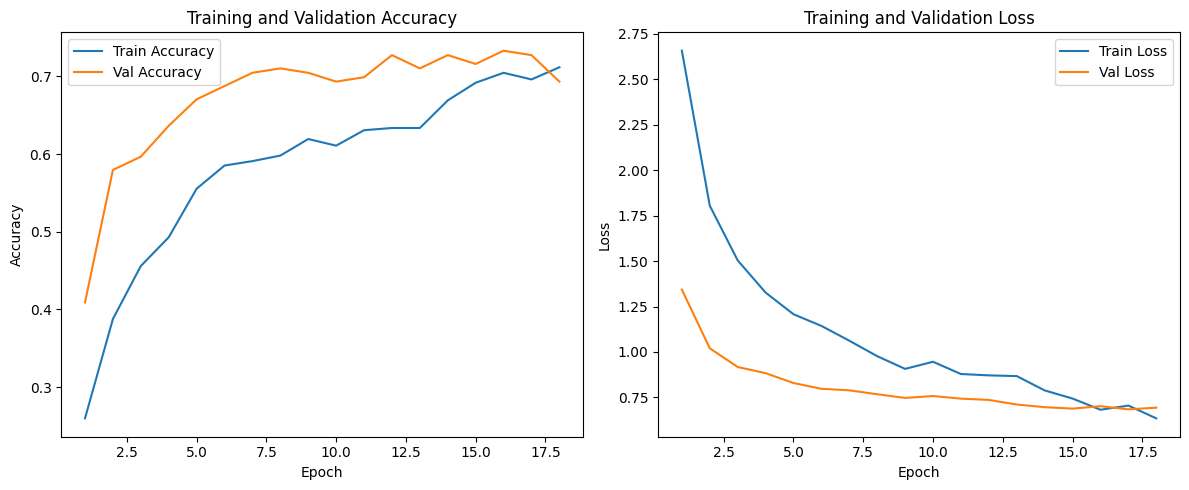

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step

Validation classification report:

              precision    recall  f1-score   support

     birads1     0.9767    0.9545    0.9655        44
     birads2     0.7049    0.9773    0.8190        44
     birads3     0.6170    0.6591    0.6374        44
     birads4     0.5600    0.3182    0.4058        44

    accuracy                         0.7273       176
   macro avg     0.7147    0.7273    0.7069       176
weighted avg     0.7147    0.7273    0.7069       176



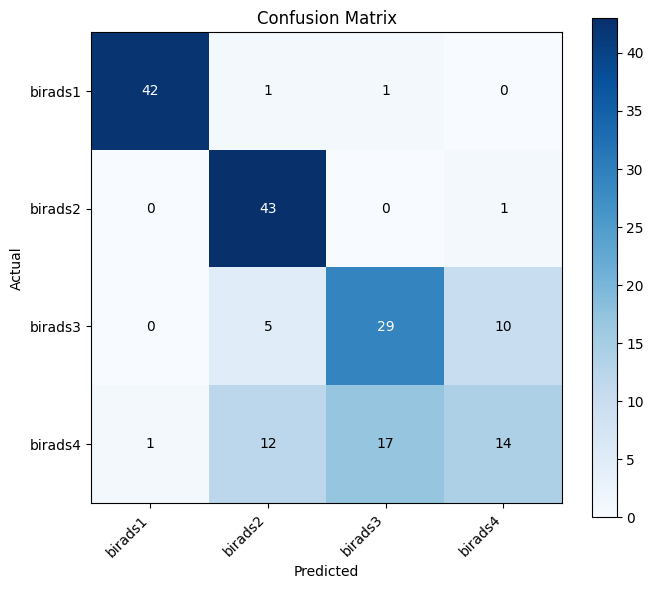

Final validation loss: 0.6848
Final validation accuracy: 0.7273


In [7]:
history_dict = merge_histories(history_stage_1, history_stage_2)
model.save(output_dir / "final_vgg16_birads.keras")
(output_dir / "class_names.json").write_text(json.dumps(class_names, indent=2))
(output_dir / "history.json").write_text(json.dumps(history_dict, indent=2))

plot_training_curves(history_dict, output_dir)
evaluate_and_save(model, val_ds, class_names, output_dir)

val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"Final validation loss: {val_loss:.4f}")
print(f"Final validation accuracy: {val_accuracy:.4f}")
